##Paso 1: Carga, Corrección Estructural y Limpieza Base
Análisis: Como descubrimos antes, el archivo tiene un formato irregular donde todas las celdas de una fila están agrupadas en una sola cadena de texto entre comillas. Este primer bloque se encarga de leer el archivo en bruto, limpiar esas comillas, estructurarlo en un DataFrame tabular, renombrar las columnas y extraer el Estado y las Fechas correctamente, filtrando el "ruido" de las filas incompletas.

In [ ]:
import pandas as pd
import io
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")

# 1. Cargar y corregir el CSV
ruta_archivo = "dataset.csv"
lineas_limpias = []

with open(ruta_archivo, "r", encoding="utf-8") as f:
    encabezado = f.readline()
    lineas_limpias.append(encabezado)
    for linea in f:
        linea = linea.strip()
        if linea.startswith('"') and linea.endswith('"'):
            linea = linea[1:-1].replace('""', '"')
        lineas_limpias.append(linea + '\n')

df = pd.read_csv(io.StringIO(''.join(lineas_limpias)))

# 2. Renombrar columnas
df.rename(columns={
    'Código Usuario': 'codigo_usuario',
    'Nombre': 'nombre',
    'Dirección': 'direccion',
    'Teléfono': 'telefono',
    'Correo Electrónico': 'correo',
    'Fecha de Alquiler': 'fecha_alquiler',
    'Fecha de Entrega': 'fecha_entrega',
    'Nombre de la Película/Video': 'pelicula',
    'Formato': 'formato'
}, inplace=True)

# 3. Limpieza y extracción de datos clave
# Extraer el Estado (2 letras antes del código postal)
df['estado'] = df['direccion'].str.extract(r'\b([A-Z]{2})\s+\d{5}(?:-\d{4})?$')[0]

# Convertir fechas (los errores='coerce' volverán NaT las fechas inválidas desplazadas)
df['fecha_alquiler'] = pd.to_datetime(df['fecha_alquiler'], errors='coerce')
df['fecha_entrega'] = pd.to_datetime(df['fecha_entrega'], errors='coerce')

print("✅ Datos cargados y limpiados exitosamente.")
print(f"Total de registros: {len(df)}")
print("\n=== PRIMERAS 3 FILAS LIMPIAS ===")
display(df.head(3))

✅ Datos cargados y limpiados exitosamente.
Total de registros: 26297

=== PRIMERAS 3 FILAS LIMPIAS ===


,codigo_usuario,nombre,direccion,telefono,correo,fecha_alquiler,fecha_entrega,pelicula,formato,estado
0,U000001,Stacy Bradley,"67188 Miranda Cove Apt. 503, Jennifertown, WA ...",(401)096-0674,shaun81@yahoo.com,2024-08-30,2024-12-17,Few hope,DVD,WA
1,U000002,Anthony Bryan,"5336 Samantha Viaduct Apt. 725, South Meganton...",478-260-4661x65637,ginawhite@heath.net,2022-10-05,2023-05-08,Food,VHS,DC
2,U000003,Nichole Cooper,"57122 Barber Pine, Blackwellland, MA 98423",139-320-7865,brian27@king-green.com,2023-07-04,2024-11-01,Radio recent similar,VHS,MA


##Paso 2: Análisis de Formatos y Películas Más Populares
Análisis: Antes de ver dónde se alquila más, es vital saber qué se está alquilando. En este paso analizaremos la distribución de los formatos físicos de las películas (para ver si predominan tecnologías antiguas como el VHS o más recientes como el Blu-ray) y mostraremos una tabla con el Top 10 de las películas más solicitadas.

/tmp/ipykernel_194/627385231.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




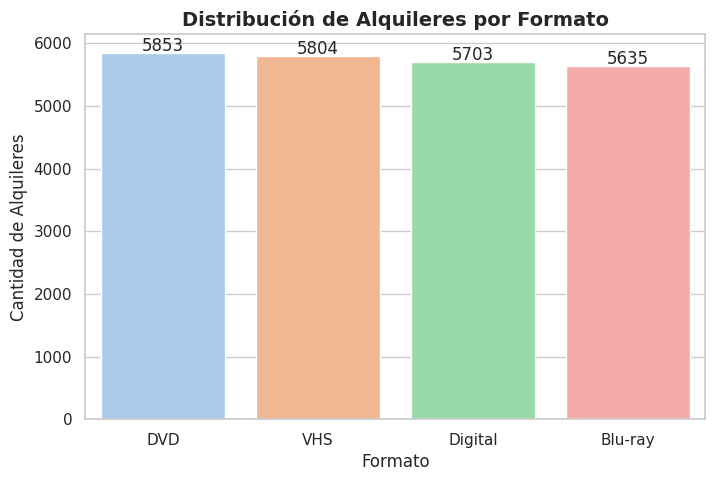


=== TOP 10 PELÍCULAS MÁS ALQUILADAS ===


,Título de la Película,Total de Alquileres
0,VHS,205
1,Blu-ray,203
2,Digital,201
3,DVD,183
4,Herself,7
5,Street,7
6,Become,7
7,Girl,7
8,Organization,6
9,Senior,6


In [ ]:
# 1. Análisis de Formatos (Gráfico de Torta / Barras)
formatos_conteo = df['formato'].value_counts()

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=formatos_conteo.index, y=formatos_conteo.values, palette='pastel')
plt.title('Distribución de Alquileres por Formato', fontsize=14, fontweight='bold')
plt.xlabel('Formato', fontsize=12)
plt.ylabel('Cantidad de Alquileres', fontsize=12)

# Añadir etiquetas a las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

# 2. Análisis de Películas (Tabla Top 10)
print("\n=== TOP 10 PELÍCULAS MÁS ALQUILADAS ===")
top_peliculas = df['pelicula'].value_counts().reset_index().head(10)
top_peliculas.columns = ['Título de la Película', 'Total de Alquileres']
display(top_peliculas)

##Paso 3: Análisis Temporal (Tendencia de Alquileres)
Análisis: Entender la estacionalidad es clave para cualquier tienda. Aquí extraeremos el Año y el Mes de la fecha_alquiler para observar cómo se han comportado los alquileres a lo largo del tiempo. Usaremos un gráfico de líneas para visualizar los picos y caídas en la demanda.

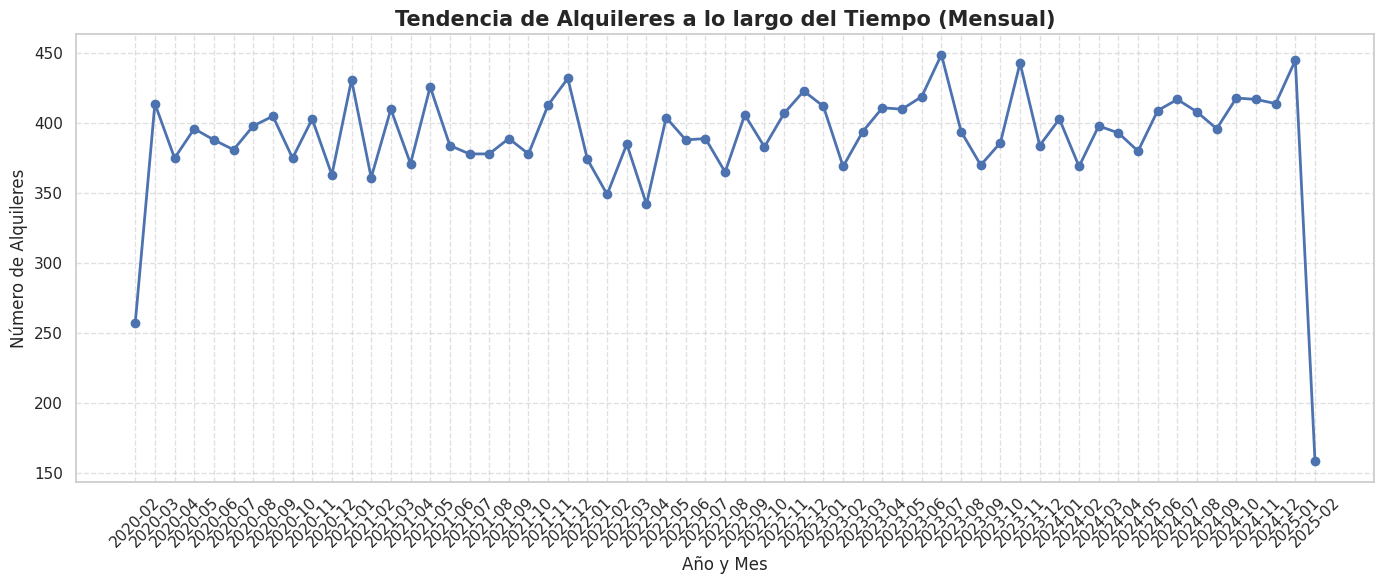


=== RESUMEN TEMPORAL ===
Fecha del primer alquiler registrado: 2020-02-11
Fecha del último alquiler registrado: 2025-02-10


In [ ]:
# 1. Preparar datos temporales (eliminar nulos en fechas)
df_temporal = df.dropna(subset=['fecha_alquiler']).copy()

# Crear una columna de "Año-Mes" para agrupar
df_temporal['año_mes'] = df_temporal['fecha_alquiler'].dt.to_period('M')
alquileres_por_mes = df_temporal['año_mes'].value_counts().sort_index()

# 2. Convertir el índice a string para poder graficarlo correctamente
alquileres_por_mes.index = alquileres_por_mes.index.astype(str)

# 3. Gráfico de Líneas Temporal
plt.figure(figsize=(14, 6))
plt.plot(alquileres_por_mes.index, alquileres_por_mes.values, marker='o', color='b', linestyle='-', linewidth=2)

plt.title('Tendencia de Alquileres a lo largo del Tiempo (Mensual)', fontsize=15, fontweight='bold')
plt.xlabel('Año y Mes', fontsize=12)
plt.ylabel('Número de Alquileres', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Tabla resumen descriptiva de las fechas
print("\n=== RESUMEN TEMPORAL ===")
print(f"Fecha del primer alquiler registrado: {df_temporal['fecha_alquiler'].min().date()}")
print(f"Fecha del último alquiler registrado: {df_temporal['fecha_alquiler'].max().date()}")

##Paso 4: Análisis Geográfico (Mayor Número de Alquileres por Estado)
Análisis: Finalmente, abordamos tu pregunta inicial. Agruparemos la información usando la columna estado que extrajimos en el Paso 1. Dado que las bases militares (AA, AE, AP) distorsionan la visión de los estados territoriales de EE.UU., calcularemos el Top 10 general y separaremos el insight para descubrir cuál es el estado civil con mayor demanda.

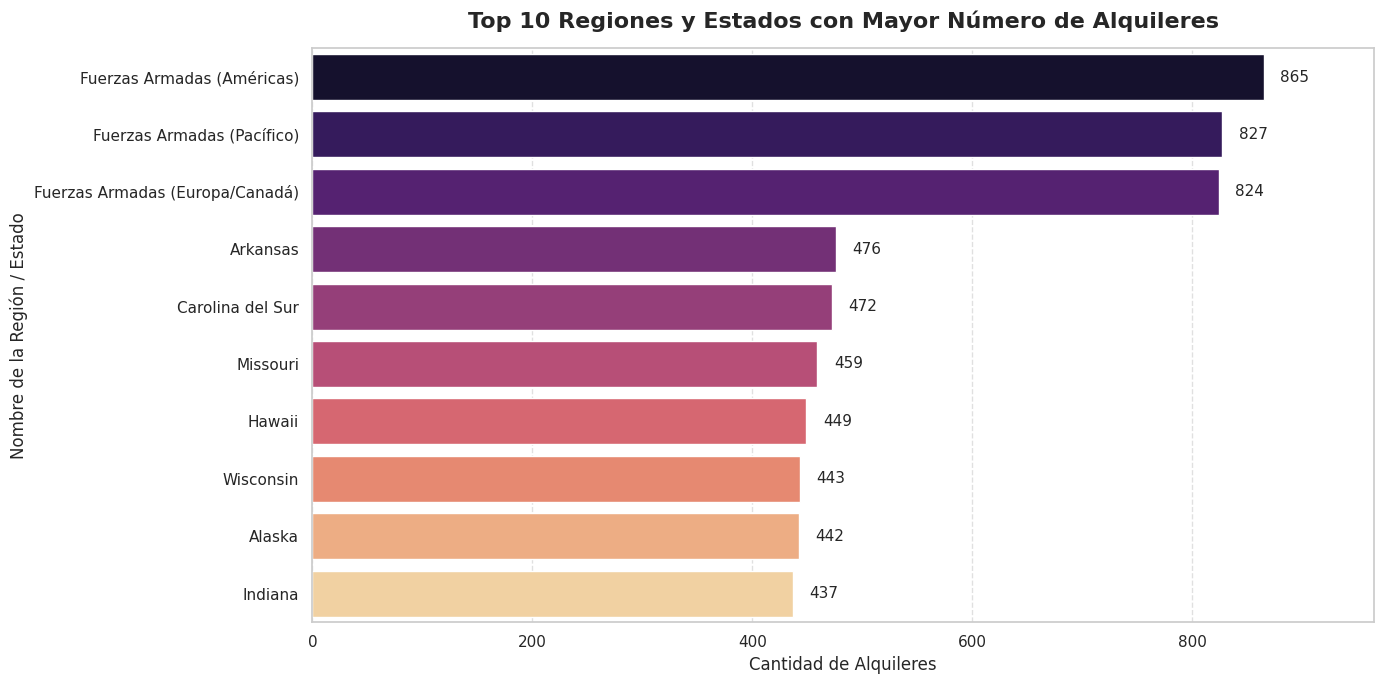


🏆 RESPUESTA A LA PREGUNTA INICIAL (DATOS MAPEADOS) 🏆
📍 Mayor número de alquileres (Absoluto): 'Fuerzas Armadas (Américas)' lidera con 865 alquileres.
📍 Mayor número de alquileres (Estado Civil): El estado de 'Arkansas' es el territorio tradicional con más alquileres, sumando un total de 476.

=== TABLA DE DATOS (TOP 10 ESTADOS) ===


,Estado,Total_Alquileres
0,Fuerzas Armadas (Américas),865
1,Fuerzas Armadas (Pacífico),827
2,Fuerzas Armadas (Europa/Canadá),824
3,Arkansas,476
4,Carolina del Sur,472
5,Missouri,459
6,Hawaii,449
7,Wisconsin,443
8,Alaska,442
9,Indiana,437


In [ ]:
# 1. Diccionario de mapeo de Códigos a Nombres Completos (Incluyendo Bases Militares)
mapa_estados = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia',
    'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi', 'MO': 'Missouri',
    'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey',
    'NM': 'New Mexico', 'NY': 'Nueva York', 'NC': 'Carolina del Norte', 'ND': 'Dakota del Norte', 'OH': 'Ohio',
    'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pensilvania', 'RI': 'Rhode Island', 'SC': 'Carolina del Sur',
    'SD': 'Dakota del Sur', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont',
    'VA': 'Virginia', 'WA': 'Washington', 'WV': 'Virginia Occidental', 'WI': 'Wisconsin', 'WY': 'Wyoming',
    'DC': 'Distrito de Columbia', 'PR': 'Puerto Rico',
    # Códigos Militares
    'AA': 'Fuerzas Armadas (Américas)',
    'AE': 'Fuerzas Armadas (Europa/Canadá)',
    'AP': 'Fuerzas Armadas (Pacífico)'
}

# 2. Aplicar el mapeo para crear una nueva columna descriptiva
df['nombre_estado'] = df['estado'].map(mapa_estados)

# Rellenar los que no cruzaron con el código original para no perderlos visualmente (por si acaso)
df['nombre_estado'] = df['nombre_estado'].fillna(df['estado'])

# 3. Contar alquileres usando los Nombres Completos
alquileres_estado = df['nombre_estado'].value_counts().reset_index()
alquileres_estado.columns = ['Estado', 'Total_Alquileres']

# 4. Identificar absolutos y civiles (excluyendo los que empiezan con "Fuerzas Armadas")
estado_absoluto = alquileres_estado.iloc[0]
alquileres_civiles = alquileres_estado[~alquileres_estado['Estado'].str.contains('Fuerzas Armadas', na=False)]
estado_civil = alquileres_civiles.iloc[0]

# 5. Gráfico de Barras del Top 10 Estados (Mejorado)
top_10_estados = alquileres_estado.head(10)

plt.figure(figsize=(14, 7)) # Hicimos la gráfica un poco más ancha para los nombres largos
ax = sns.barplot(data=top_10_estados, x='Total_Alquileres', y='Estado', hue='Estado', palette='magma', legend=False) # Invertimos los ejes para mejor lectura

plt.title('Top 10 Regiones y Estados con Mayor Número de Alquileres', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Cantidad de Alquileres', fontsize=12)
plt.ylabel('Nombre de la Región / Estado', fontsize=12)

# Añadir etiquetas de datos al final de cada barra horizontal
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width() + 15, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=11)

plt.xlim(0, top_10_estados['Total_Alquileres'].max() + 100) # Dar espacio para los números
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 6. Conclusiones Finales (Insights)
print("\n" + "="*60)
print("🏆 RESPUESTA A LA PREGUNTA INICIAL (DATOS MAPEADOS) 🏆")
print("="*60)
print(f"📍 Mayor número de alquileres (Absoluto): '{estado_absoluto['Estado']}' lidera con {estado_absoluto['Total_Alquileres']} alquileres.")
print(f"📍 Mayor número de alquileres (Estado Civil): El estado de '{estado_civil['Estado']}' es el territorio tradicional con más alquileres, sumando un total de {estado_civil['Total_Alquileres']}.")

print("\n=== TABLA DE DATOS (TOP 10 ESTADOS) ===")
display(top_10_estados)

##Paso 5 Nuevo: Mapa Interactivo de Estados Unidos (Choropleth Map)
Para que el mapa de EE.UU. funcione correctamente, necesitamos usar los códigos de 2 letras originales (ej. TX, CA, FL), ya que las librerías de mapeo no reconocen los nombres en español ni las bases militares. Crearemos una celda nueva para esto utilizando Plotly.

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd

# 1. Separar datos civiles y militares
estados_militares = ['AA', 'AE', 'AP']
df_usa = df[~df['estado'].isin(estados_militares)].copy()
df_militares = df[df['estado'].isin(estados_militares)].copy()

# Agrupaciones
alquileres_usa = df_usa.groupby(['estado', 'nombre_estado']).size().reset_index(name='Total')
alquileres_mil = df_militares['estado'].value_counts()

# 2. Crear datos para el mapa global (Bases Militares)
zonas_militares = {
    'CAN': 'AE', 'GBR': 'AE', 'DEU': 'AE', 'ITA': 'AE', 'ESP': 'AE', 'FRA': 'AE', # Europa/Canadá
    'JPN': 'AP', 'KOR': 'AP', 'AUS': 'AP', 'PHL': 'AP',                           # Pacífico (Australia, etc.)
    'MEX': 'AA', 'COL': 'AA', 'BRA': 'AA', 'PER': 'AA', 'PAN': 'AA', 'CHL': 'AA'  # Américas
}

datos_mapa_global = []
for pais_iso, codigo_base in zonas_militares.items():
    datos_mapa_global.append({
        'ISO_A3': pais_iso,
        'Total': alquileres_mil.get(codigo_base, 0),
        'Comando': mapa_estados.get(codigo_base, codigo_base)
    })
df_global = pd.DataFrame(datos_mapa_global)

# 3. Crear Subplots (1 Fila, 2 Columnas)
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "choropleth"}, {"type": "choropleth"}]],
    subplot_titles=("Zonas Militares (Australia, Europa, Américas)", "Alquileres por Estado (EE.UU.)"),
    column_widths=[0.45, 0.55]
)

# 4. Trazar el Mapa Global (Lado Izquierdo) - AHORA CON MAPA DE CALOR
fig.add_trace(
    go.Choropleth(
        locations=df_global['ISO_A3'],
        z=df_global['Total'],
        text=df_global['Comando'],
        colorscale="YlOrRd", # <--- Paleta de punto de calor (Amarillo a Rojo)
        showscale=False,
        marker_line_color='darkgray',
        marker_line_width=0.5
    ),
    row=1, col=1
)

# 5. Trazar el Mapa de EE.UU. (Lado Derecho) - AHORA CON MAPA DE CALOR
fig.add_trace(
    go.Choropleth(
        locations=alquileres_usa['estado'],
        z=alquileres_usa['Total'],
        locationmode="USA-states",
        colorscale="YlOrRd", # <--- Paleta de punto de calor (Amarillo a Rojo)
        colorbar_title="Alquileres",
        marker_line_color='darkgray',
        marker_line_width=0.5
    ),
    row=1, col=2
)

# 6. Superponer nombres completos sin negrilla en EE.UU.
alquileres_usa['texto_etiqueta'] = alquileres_usa['nombre_estado'] + "<br>" + alquileres_usa['Total'].astype(str)

# Para un mapa de calor que se vuelve muy oscuro (rojo), el texto blanco resalta mejor
fig.add_trace(
    go.Scattergeo(
        locations=alquileres_usa['estado'],
        locationmode='USA-states',
        text=alquileres_usa['texto_etiqueta'],
        mode='text',
        textfont=dict(size=7, color='black', family="Arial"), # Negro sobre amarillo/naranja
    ),
    row=1, col=2
)

# 7. Ajustar configuraciones individuales de cada mapa
fig.update_geos(
    showcoastlines=True, coastlinecolor="LightBlue",
    projection_type="equirectangular",
    row=1, col=1
)

fig.update_geos(
    scope="usa",
    row=1, col=2
)

# 8. Diseño general
fig.update_layout(
    height=600,
    margin={"r":0,"t":50,"l":0,"b":0},
    title_text="Dashboard Geográfico: Bases Internacionales y Estados de EE.UU.",
    title_x=0.5
)

fig.show()

La conclusión a la que se llega observando los datos es que la demanda de alquiler de peliculas durante 5 años es demasiado baja para llevar a cabo una operación a nivel mundial sumado a que el negocio convencional requiere de una infraestructura con altos costos de mantenimiento. Las plataformas de streaming actuales ofrecen un catálogo completo con una sola suscripción mientras que el alquiler fisico de las peliculas acarrea mayor logistica. Sin embargo, observamos un comportamiento inusual con las bases militares, creemos que es debido a la falta de conectividad y por ende para ellos si es necesario tener en fisico las peliculas